In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D,Flatten,MaxPooling2D,Dropout
from tensorflow.keras.utils import to_categorical

In [6]:
from keras.datasets import mnist


# load dataset
(x_train, y_train),(x_test, y_test) = mnist.load_data()

In [7]:
x_test

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [8]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [9]:
y_test

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [10]:
x_train.shape

(60000, 28, 28)

In [11]:
x_test.shape

(10000, 28, 28)

In [12]:
x_train= x_train.astype("float32")/255
x_test= x_test.astype("float32")/255

In [13]:
x_train_img = x_train.reshape(-1,28,28)
x_test_img = x_test.reshape(-1,28,28)

In [14]:
x_train_img.shape

(60000, 28, 28)

In [15]:
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

In [16]:
y_train_cat.shape

(60000, 10)

In [17]:
Perceptron = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10,activation="softmax")
])

In [18]:
Perceptron.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])


In [19]:
history_percp = Perceptron.fit(x_train_img,
                               y_train_cat,
                               epochs=10,
                               batch_size=32,
                               validation_data=(x_test_img,y_test_cat))



Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8784 - loss: 0.4639 - val_accuracy: 0.9144 - val_loss: 0.3071
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9151 - loss: 0.3031 - val_accuracy: 0.9192 - val_loss: 0.2864
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9207 - loss: 0.2834 - val_accuracy: 0.9235 - val_loss: 0.2744
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9237 - loss: 0.2728 - val_accuracy: 0.9253 - val_loss: 0.2704
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9257 - loss: 0.2664 - val_accuracy: 0.9240 - val_loss: 0.2697
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9272 - loss: 0.2617 - val_accuracy: 0.9271 - val_loss: 0.2675
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9290 - loss: 0.2585 - val_accuracy: 0.9267 - val_loss: 0.2641
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9291 - loss: 0.2551 - 

In [20]:
acc_percep = Perceptron.evaluate(x_test_img,y_test_cat, verbose = 0)[1]

In [21]:
acc_percep

0.9271000027656555

ANN

In [22]:
ann = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation="relu"),
    Dense(64,activation="relu"),
    Dense(10,activation="softmax")
])

In [23]:
ann.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

In [24]:
history_ann = ann.fit(x_train_img,
                      y_train_cat,
                      epochs=5,
                      batch_size=128,
                      validation_data=(x_test_img,y_test_cat))

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9073 - loss: 0.3209 - val_accuracy: 0.9530 - val_loss: 0.1564
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9616 - loss: 0.1300 - val_accuracy: 0.9684 - val_loss: 0.1084
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9734 - loss: 0.0907 - val_accuracy: 0.9649 - val_loss: 0.1116
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9789 - loss: 0.0699 - val_accuracy: 0.9731 - val_loss: 0.0890
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9833 - loss: 0.0540 - val_accuracy: 0.9725 - val_loss: 0.0885


In [25]:
acc_ann =ann.evaluate(x_test_img,y_test_cat, verbose = 0)[1]

In [26]:
acc_ann

0.9725000262260437

CNN

In [27]:
x_train_cnn= x_train.reshape(-1,28,28,1)
x_test_cnn= x_test.reshape(-1,28,28,1)

In [28]:
cnn = Sequential([
    Conv2D(32, kernel_size=(3,3),activation="relu",input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3),activation="relu"),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128,activation="relu"),
    Dropout(0.5),
    Dense(10,activation="softmax")
])

In [29]:
cnn.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

In [30]:
history_cnn = cnn.fit(x_train_cnn,
              y_train_cat,
              epochs=3,
              batch_size=32,
              validation_data=(x_test_cnn,y_test_cat))

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.9283 - loss: 0.2326 - val_accuracy: 0.9858 - val_loss: 0.0438
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 31ms/step - accuracy: 0.9754 - loss: 0.0847 - val_accuracy: 0.9883 - val_loss: 0.0350
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.9821 - loss: 0.0621 - val_accuracy: 0.9903 - val_loss: 0.0315


In [31]:
acc_cnn = cnn.evaluate(x_test_cnn,y_test_cat, verbose = 0)[1]   

In [32]:
# acc_cnn = history_cnn.evaluate(x_test_cnn,y_test_cat, verbose = 0)[1]

In [33]:
acc_cnn

0.9902999997138977

In [34]:
def plot_training(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="Val")
    plt.title(f"{title} Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Val")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()

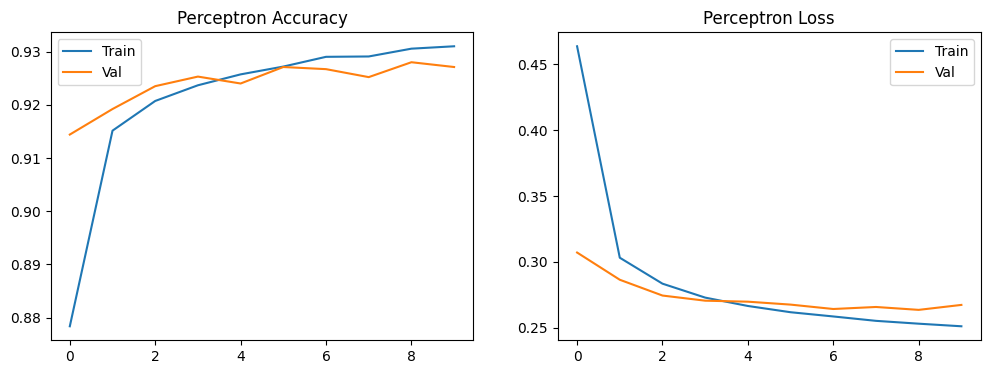

In [35]:
plot_training(history_percp, "Perceptron")

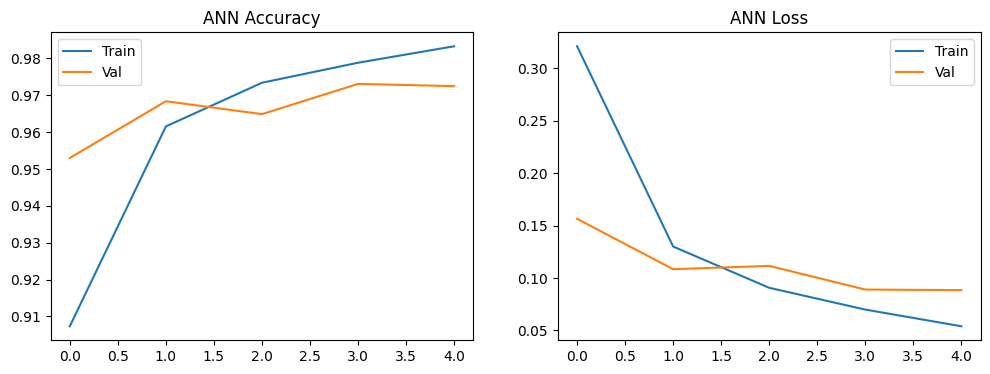

In [36]:
plot_training(history_ann, "ANN")

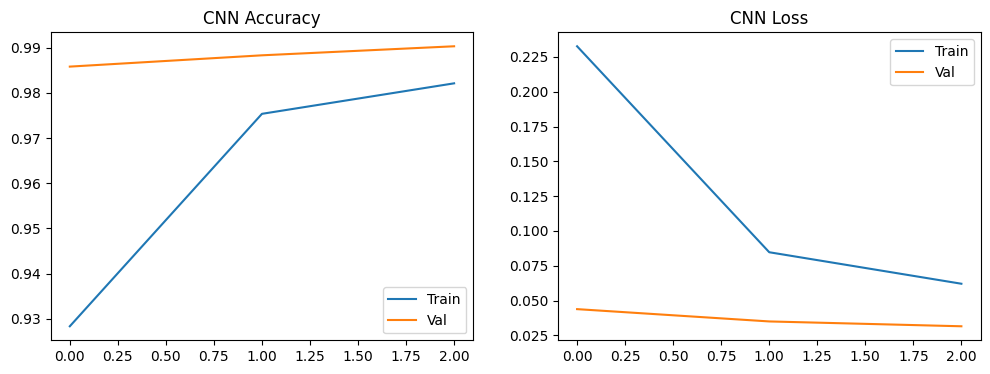

In [37]:
plot_training(history_cnn, "CNN")


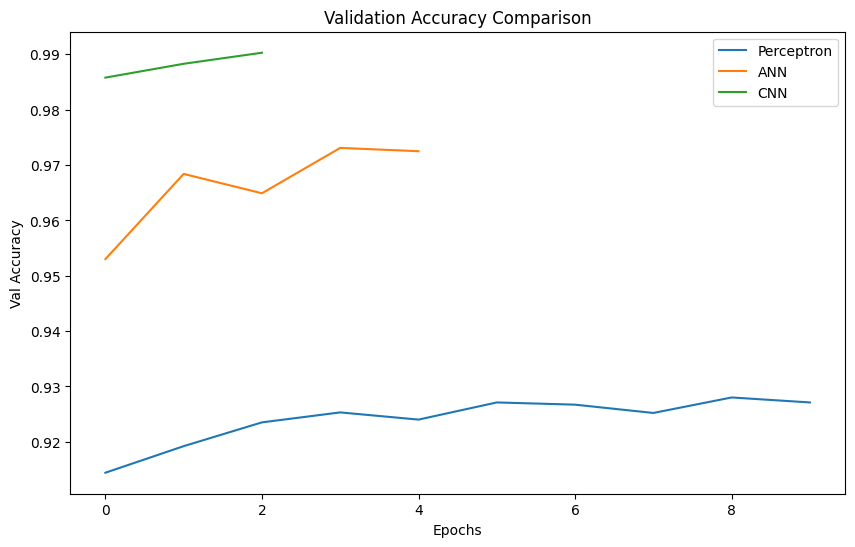

In [38]:
plt.figure(figsize=(10,6))
plt.plot(history_percp.history['val_accuracy'], label="Perceptron")
plt.plot(history_ann.history['val_accuracy'], label="ANN")
plt.plot(history_cnn.history['val_accuracy'], label="CNN")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Val Accuracy")
plt.legend()
plt.show()

In [39]:

def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs):
        plt.subplot(2, n, i+1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"True: {y_true[idx]}")
        preds = [np.argmax(model.predict(X_cnn[idx].reshape(1, 28, 28, 1) if name == "CNN" else X[idx].reshape(1, 28, 28)))
                 for model, name in zip(models, model_names)]
        plt.subplot(2, n, n+i+1)
        plt.axis("off")
        plt.title("\n".join(f"{n}: {p}" for n, p in zip(model_names, preds)))
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


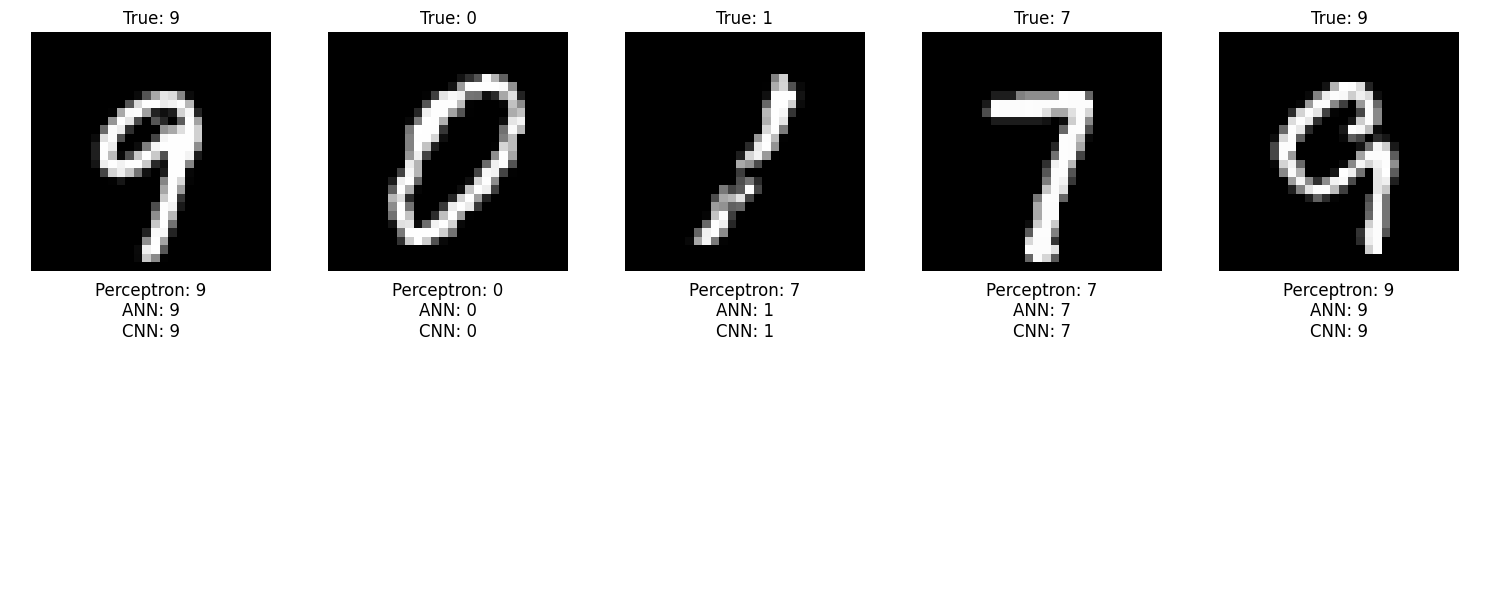

In [40]:
show_side_by_side([Perceptron, ann, cnn], ["Perceptron", "ANN", "CNN"], x_test_img, x_test_cnn, y_test, 5)


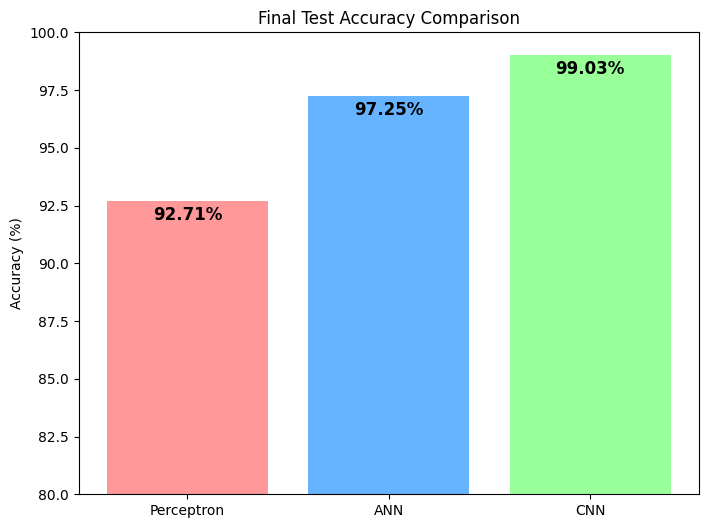

In [41]:
final_accs = [acc_percep*100, acc_ann*100, acc_cnn*100]
models = ["Perceptron", "ANN", "CNN"]

plt.figure(figsize=(8,6))
bars = plt.bar(models, final_accs, color=['#ff9999','#66b3ff','#99ff99'])
plt.title("Final Test Accuracy Comparison")
plt.ylabel("Accuracy (%)")
for bar, acc in zip(bars, final_accs):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()-1, f"{acc:.2f}%",
             ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.ylim(80, 100)
plt.show()


In [42]:
cnn.save("cnn.keras")

from tensorflow.keras.models import load_model

test_model = load_model("cnn.keras", compile=False)

print("Loaded successfully!")

Loaded successfully!


In [43]:
from google.colab import files

files.download("cnn.keras")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
import tensorflow as tf
print(tf.__version__)


2.20.0
